# 🔧 Telecom QoE — Feature Engineering Notebook
**Goal**: Transform raw KPIs into ML-ready features that maximise predictive signal for `qoe_score` / `qoe_category`

### Table of Contents
1. Setup & Data Import
2. Baseline Feature Review  
3. Domain-Derived Features  
4. Interaction & Ratio Features  
5. Polynomial & Non-linear Features  
6. Binning & Ordinal Encoding  
7. Aggregated / Statistical Features  
8. App-Specific Feature Flags  
9. Feature Scaling  
10. Feature Selection (Filter + Wrapper + Embedded)  
11. Final Feature Matrix  
12. Export


## 1  Setup & Data Generation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.stats import truncnorm, spearmanr
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    PolynomialFeatures, LabelEncoder
)
from sklearn.feature_selection import (
    mutual_info_regression, mutual_info_classif,
    SelectKBest, f_regression, RFE
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 5)})

APP_COLORS = {"video": "#4C72B0", "volte": "#DD8452", "gaming": "#55A868"}
CAT_ORDER  = ["Poor", "Fair", "Good", "Excellent"]


In [2]:
df_raw = pd.read_csv("../Data generation/telecom_qoe_dataset.csv")
RAW_KPI  = ["throughput","latency","packet_loss","sinr","rsrp",
            "cell_load","prb_utilization","mobility"]
TARGET_R = "qoe_score"
TARGET_C = "qoe_category"

print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()


Raw dataset shape: (5000, 12)


,imsi,app,throughput,latency,packet_loss,sinr,rsrp,cell_load,prb_utilization,mobility,qoe_score,qoe_category
0,310150634895718,gaming,4.28,42.24,2.66,4.14,-111.93,56.74,51.02,55.69,2.77,Fair
1,310150299900595,volte,12.44,13.31,0.85,11.15,-104.65,20.67,22.53,24.29,4.45,Excellent
2,310150962061404,volte,21.95,24.70,0.92,17.81,-100.75,26.28,21.41,34.17,4.28,Excellent
3,310150887846414,gaming,29.62,19.71,0.35,23.62,-91.83,27.70,33.77,44.01,4.45,Excellent
4,310150227521863,video,1.86,29.96,2.18,3.84,-102.57,67.04,61.45,18.72,2.32,Fair


## 2  Baseline Feature Review
Before engineering anything, measure the predictive power of raw KPIs
using **Spearman correlation** and **Mutual Information** with `qoe_score`.
This sets a baseline to compare engineered features against.


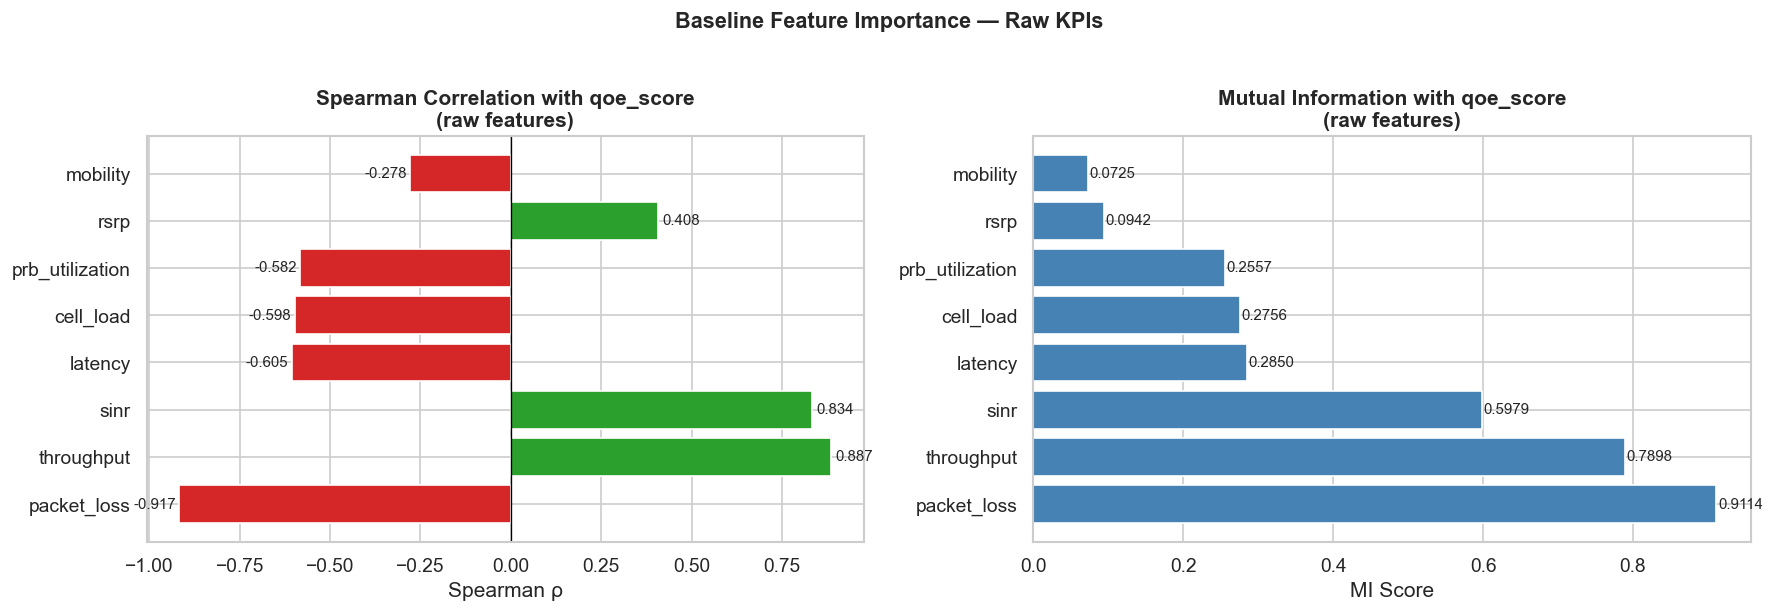


Baseline summary:


,spearman_rho,mutual_info
packet_loss,-0.9167,0.9114
throughput,0.8866,0.7898
sinr,0.8338,0.5979
latency,-0.6047,0.2850
cell_load,-0.5981,0.2756
prb_utilization,-0.5822,0.2557
rsrp,0.4077,0.0942
mobility,-0.2779,0.0725


In [3]:
# Spearman rank correlation (captures monotonic non-linear relationships)
spearman = {col: spearmanr(df_raw[col], df_raw[TARGET_R])[0] for col in RAW_KPI}
spearman_s = pd.Series(spearman).sort_values(key=abs, ascending=False)

# Mutual Information (captures any statistical dependence)
mi_scores = mutual_info_regression(df_raw[RAW_KPI], df_raw[TARGET_R], random_state=42)
mi_s = pd.Series(mi_scores, index=RAW_KPI).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_sp = ["#d62728" if v < 0 else "#2ca02c" for v in spearman_s.values]
axes[0].barh(spearman_s.index, spearman_s.values, color=colors_sp, edgecolor="white")
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Spearman Correlation with qoe_score\n(raw features)", fontweight="bold")
axes[0].set_xlabel("Spearman ρ")
for i, v in enumerate(spearman_s.values):
    axes[0].text(v + (0.01 if v>=0 else -0.01), i, f"{v:.3f}",
                 va="center", ha="left" if v>=0 else "right", fontsize=9)

axes[1].barh(mi_s.index, mi_s.values, color="steelblue", edgecolor="white")
axes[1].set_title("Mutual Information with qoe_score\n(raw features)", fontweight="bold")
axes[1].set_xlabel("MI Score")
for i, v in enumerate(mi_s.values):
    axes[1].text(v+0.002, i, f"{v:.4f}", va="center", fontsize=9)

plt.suptitle("Baseline Feature Importance — Raw KPIs", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nBaseline summary:")
pd.DataFrame({"spearman_rho": spearman_s, "mutual_info": mi_s}).round(4)


## 3  Domain-Derived Features
Features grounded in **telecom physics and 3GPP/ITU-T standards**.
Each one encodes a real-world network phenomenon that raw KPIs don't directly express.


In [4]:
df = df_raw.copy()

# ── 3.1  Shannon Capacity Estimate (bits/s/Hz) ────────────────────────
# Theoretical max throughput given SINR: C = log2(1 + SINR_linear)
# Tells us how much of the available capacity is actually being used
df["shannon_capacity"]    = np.log2(1 + 10**(df["sinr"]/10))
df["spectral_efficiency"] = df["throughput"] / df["shannon_capacity"]
# < 1  →  UE is under-served relative to what the channel allows

# ── 3.2  RSRP-to-SINR Gap ────────────────────────────────────────────
# A strong RSRP but low SINR means high inter-cell interference
# Positive gap → interference-limited cell; negative → noise-limited
df["rsrp_sinr_gap"] = df["rsrp"] - (-120 + (df["sinr"]+5)/35 * 50)
# normalised RSRP proxy used as the gap baseline

# ── 3.3  Link Quality Index (LQI) ────────────────────────────────────
# Composite signal quality: combines RSRP and SINR (both in dB scale)
# Higher = better radio conditions
df["lqi"] = (df["sinr"] - df["sinr"].min()) / (df["sinr"].max() - df["sinr"].min()) * 0.6           + (df["rsrp"] - df["rsrp"].min()) / (df["rsrp"].max() - df["rsrp"].min()) * 0.4

# ── 3.4  Cell Congestion Index ────────────────────────────────────────
# Combines cell_load and prb_utilization into a single congestion score
# M/M/1 saturation: congestion spikes non-linearly above 80 %
df["congestion_index"] = (df["cell_load"] * 0.5 + df["prb_utilization"] * 0.5) / 100
df["congestion_index_sq"] = df["congestion_index"] ** 2   # non-linear saturation

# ── 3.5  Goodput Efficiency ───────────────────────────────────────────
# Effective throughput after removing packet-loss overhead
# Models what the application actually receives
df["goodput"] = df["throughput"] * (1 - df["packet_loss"] / 100)

# ── 3.6  Handover Risk Score ─────────────────────────────────────────
# High mobility + poor RSRP → likely frequent handovers → instability
df["ho_risk"] = (df["mobility"] / 120) *                 (1 - (df["rsrp"] - (-120)) / 50)
df["ho_risk"] = np.clip(df["ho_risk"], 0, 1)

# ── 3.7  E-Model R-Factor Proxy (VoLTE-inspired) ─────────────────────
# Simplified ITU-T G.107 R-factor: R = 93.2 – Id – Ie
# Id = delay impairment, Ie = equipment/loss impairment
# We apply it globally as a signal quality proxy
Id   = 0.024 * df["latency"] + 0.11 * (df["latency"] - 177.3) * (df["latency"] > 177.3).astype(int)
Ie   = 7 + 30 * np.log(1 + 15 * df["packet_loss"] / 100)
df["r_factor_proxy"] = np.clip(93.2 - Id - Ie, 0, 100)
df["mos_from_r"]     = np.where(
    df["r_factor_proxy"] < 0, 1,
    np.where(df["r_factor_proxy"] > 100, 4.5,
             1 + 0.035*df["r_factor_proxy"] +
             df["r_factor_proxy"]*(df["r_factor_proxy"]-60)*(100-df["r_factor_proxy"])*7e-6))
df["mos_from_r"] = np.clip(df["mos_from_r"], 1, 5)

new_domain = ["shannon_capacity","spectral_efficiency","rsrp_sinr_gap",
              "lqi","congestion_index","congestion_index_sq",
              "goodput","ho_risk","r_factor_proxy","mos_from_r"]

print(f"Domain features added: {len(new_domain)}")
df[new_domain].describe().T.round(3)


Domain features added: 10


,count,mean,std,min,25%,50%,75%,max
shannon_capacity,5000.0,3.568,2.094,0.396,1.872,3.348,4.935,9.967
spectral_efficiency,5000.0,2.936,1.369,0.196,2.128,3.184,3.750,19.954
rsrp_sinr_gap,5000.0,0.187,9.612,-34.210,-6.346,-0.096,6.796,30.684
lqi,5000.0,0.427,0.164,0.000,0.309,0.428,0.539,0.924
congestion_index,5000.0,0.480,0.212,0.100,0.308,0.440,0.673,0.972
congestion_index_sq,5000.0,0.276,0.216,0.010,0.095,0.193,0.453,0.944
goodput,5000.0,11.370,8.314,0.478,4.349,10.553,16.857,39.886
ho_risk,5000.0,0.178,0.136,0.000,0.072,0.148,0.249,0.859
r_factor_proxy,5000.0,79.528,3.650,63.698,77.119,79.829,82.247,86.080
mos_from_r,5000.0,3.999,0.143,3.289,3.911,4.018,4.106,4.232


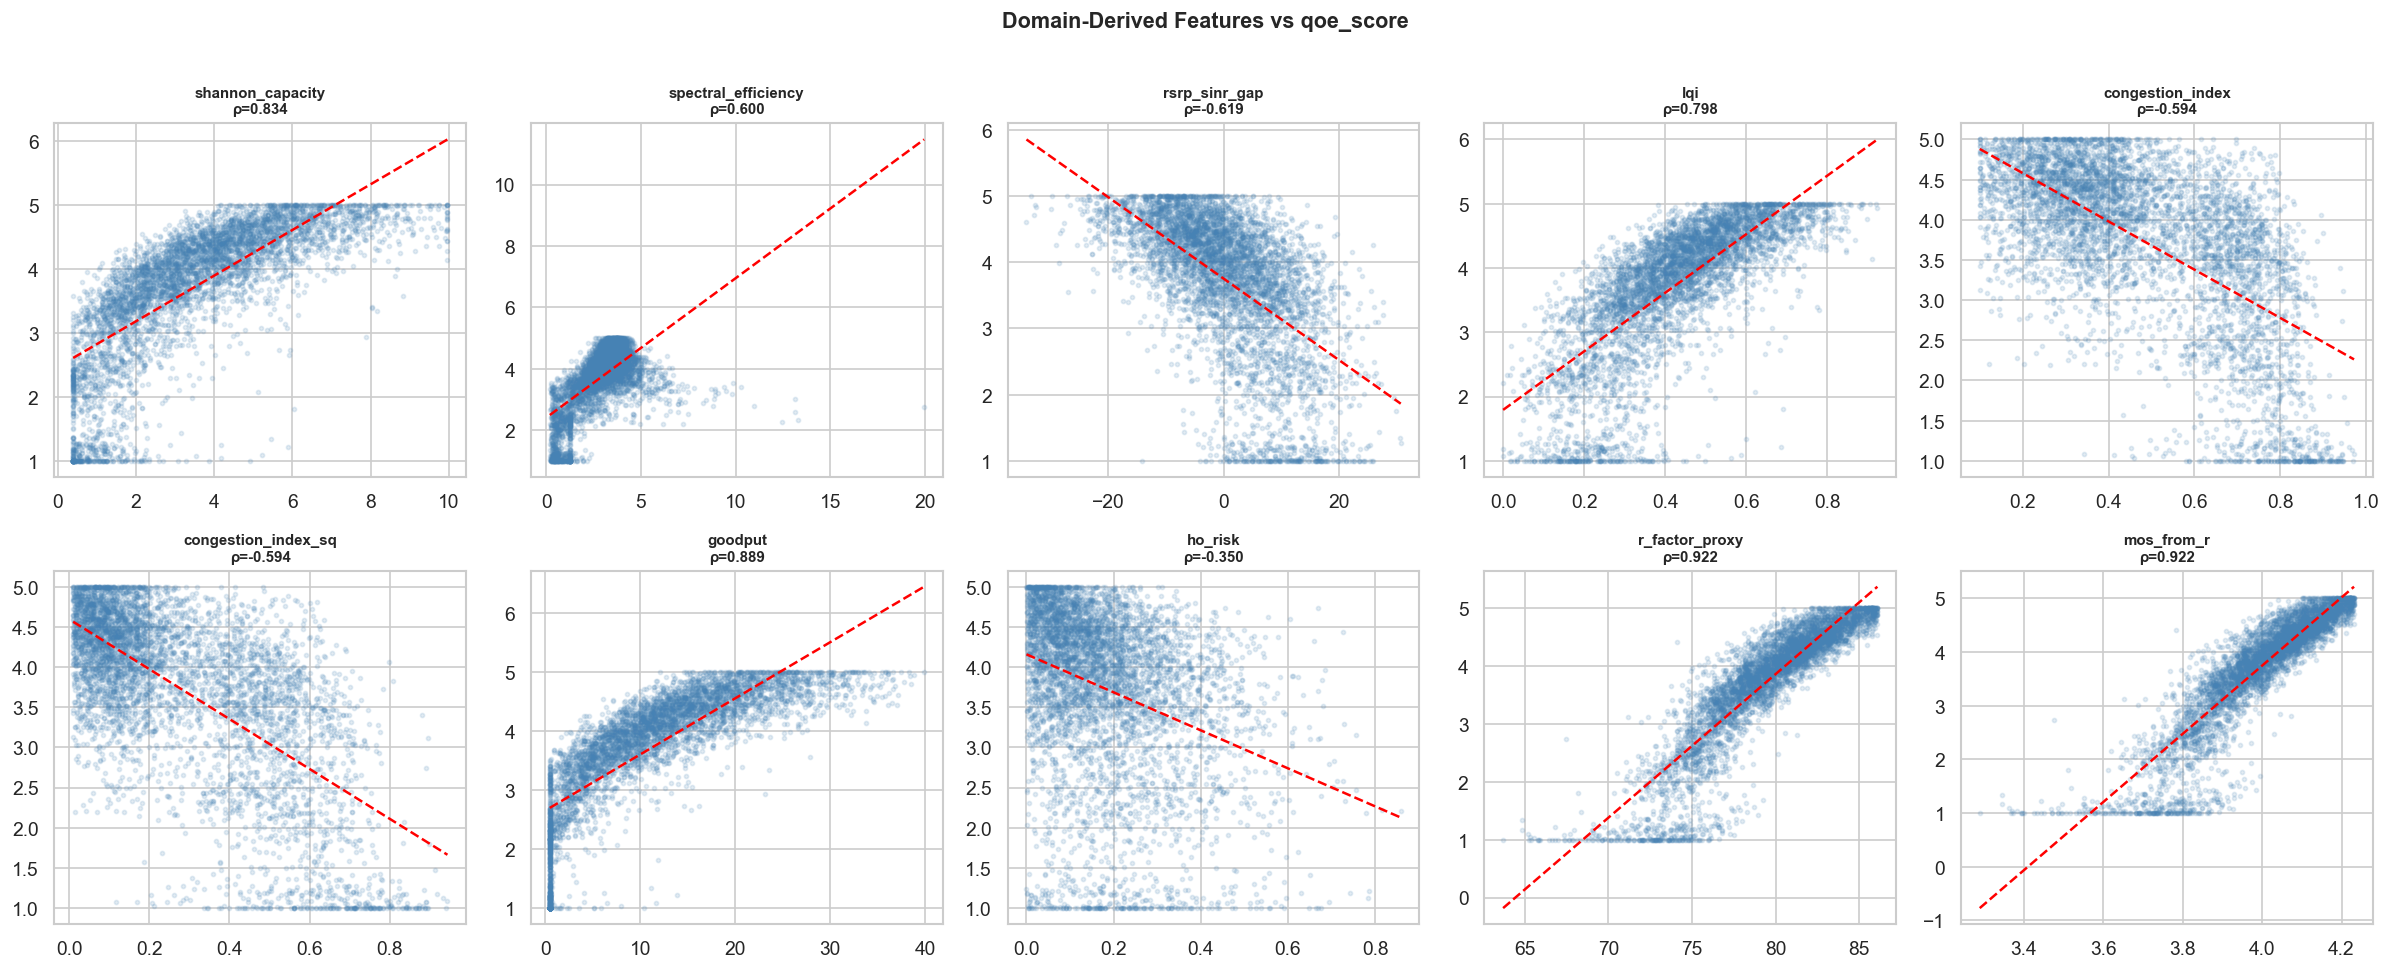

In [5]:
# Visualise domain features vs qoe_score
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for ax, col in zip(axes, new_domain):
    ax.scatter(df[col], df[TARGET_R], alpha=0.15, s=6, color="steelblue")
    z = np.polyfit(df[col], df[TARGET_R], 1)
    xr = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(xr, np.polyval(z, xr), "r--", lw=1.5)
    rho = spearmanr(df[col], df[TARGET_R])[0]
    ax.set_title(f"{col}\nρ={rho:.3f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("")
plt.suptitle("Domain-Derived Features vs qoe_score", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 4  Interaction & Ratio Features
Multiplicative and ratio combinations that capture **joint effects**
two raw KPIs cannot express individually.


In [6]:
# ── 4.1  Throughput-to-Latency Ratio ─────────────────────────────────
# High tput + low latency = great experience; this ratio encodes both
df["tput_lat_ratio"]   = df["throughput"] / (df["latency"] + 1)   # +1 avoids div/0

# ── 4.2  SINR × Throughput ───────────────────────────────────────────
# Joint signal quality × delivered rate
df["sinr_x_tput"]      = df["sinr"] * df["throughput"]

# ── 4.3  Loss × Latency (compound impairment) ────────────────────────
# Both degrading simultaneously is far worse than either alone
df["loss_x_latency"]   = df["packet_loss"] * df["latency"]

# ── 4.4  Load × Mobility (instability index) ─────────────────────────
# Congested cell + fast-moving UE = worst-case scenario
df["load_x_mobility"]  = df["cell_load"] * df["mobility"]

# ── 4.5  SINR per PRB unit (spectral density proxy) ──────────────────
df["sinr_per_prb"]     = df["sinr"] / (df["prb_utilization"] + 1)

# ── 4.6  Goodput-to-Latency Ratio ────────────────────────────────────
# Effective throughput relative to responsiveness
df["goodput_lat_ratio"] = df["goodput"] / (df["latency"] + 1)

# ── 4.7  Free PRB Ratio ───────────────────────────────────────────────
# How much scheduling headroom remains (1 − utilisation)
df["free_prb_ratio"]   = 1 - df["prb_utilization"] / 100

# ── 4.8  Signal × Free Capacity ──────────────────────────────────────
# Good signal AND free capacity = likely high QoE
df["lqi_x_free_prb"]   = df["lqi"] * df["free_prb_ratio"]

new_interaction = ["tput_lat_ratio","sinr_x_tput","loss_x_latency",
                   "load_x_mobility","sinr_per_prb","goodput_lat_ratio",
                   "free_prb_ratio","lqi_x_free_prb"]

print(f"Interaction features added: {len(new_interaction)}")
df[new_interaction].describe().T.round(3)


Interaction features added: 8


,count,mean,std,min,25%,50%,75%,max
tput_lat_ratio,5000.0,0.570,0.696,0.002,0.110,0.369,0.780,6.438
sinr_x_tput,5000.0,168.773,200.340,-39.550,16.555,103.199,248.400,1202.100
loss_x_latency,5000.0,66.051,90.440,0.000,15.175,36.200,81.397,880.000
load_x_mobility,5000.0,1777.266,1457.801,0.000,693.187,1378.254,2473.825,10141.522
sinr_per_prb,5000.0,0.306,0.344,-0.455,0.081,0.217,0.424,2.712
goodput_lat_ratio,5000.0,0.565,0.693,0.002,0.108,0.365,0.773,6.420
free_prb_ratio,5000.0,0.550,0.202,0.037,0.372,0.579,0.714,0.900
lqi_x_free_prb,5000.0,0.246,0.146,0.000,0.127,0.225,0.343,0.795


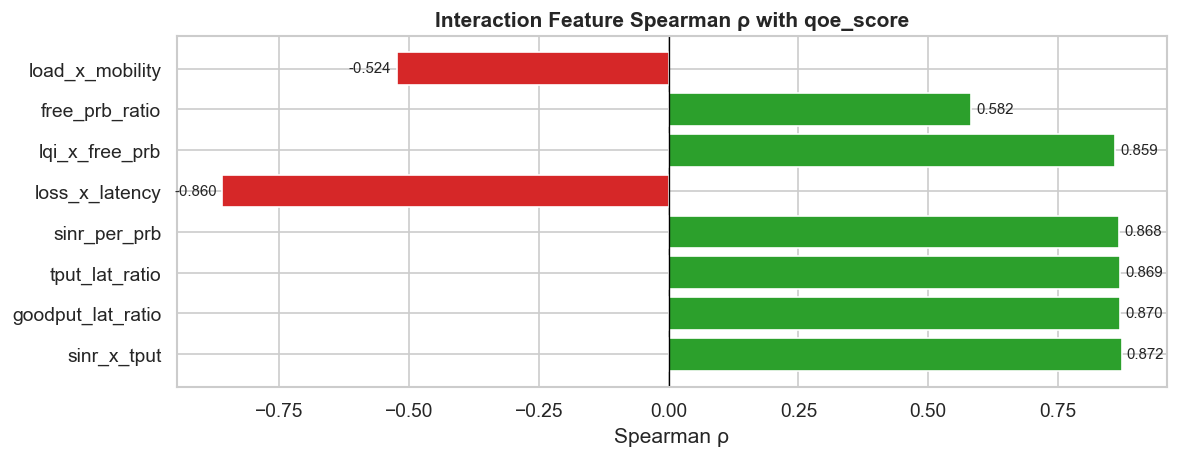

In [7]:
# Spearman correlation of interaction features with qoe_score
int_corr = pd.Series(
    {col: spearmanr(df[col], df[TARGET_R])[0] for col in new_interaction}
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2ca02c" if v>=0 else "#d62728" for v in int_corr.values]
ax.barh(int_corr.index, int_corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Interaction Feature Spearman ρ with qoe_score", fontweight="bold")
ax.set_xlabel("Spearman ρ")
for i, v in enumerate(int_corr.values):
    ax.text(v + (0.01 if v>=0 else -0.01), i, f"{v:.3f}",
            va="center", ha="left" if v>=0 else "right", fontsize=9)
plt.tight_layout()
plt.show()


## 5  Polynomial & Non-linear Transformations
Raw KPIs often have **non-linear** relationships with QoE
(e.g. latency impact is near-zero at 20 ms but catastrophic at 150 ms).
Log, square-root and square transforms expose these curves.


In [9]:
# ── 5.1  Log transforms (compress right-skewed distributions) ─────────
# Throughput, latency, and packet_loss are right-skewed
df["log_throughput"]  = np.log1p(df["throughput"])     # log(1+x) safe for 0
df["log_latency"]     = np.log1p(df["latency"])
df["log_packet_loss"] = np.log1p(df["packet_loss"])
df["log_mobility"]    = np.log1p(df["mobility"])

# ── 5.2  Square-root transforms (moderate compression) ───────────────
df["sqrt_throughput"] = np.sqrt(df["throughput"])
df["sqrt_cell_load"]  = np.sqrt(df["cell_load"])

# ── 5.3  Square (amplify large values — congestion cliff) ─────────────
df["cell_load_sq"]    = df["cell_load"] ** 2
df["latency_sq"]      = df["latency"] ** 2
df["packet_loss_sq"]  = df["packet_loss"] ** 2

# ── 5.4  Exponential decay of SINR (models link quality saturation) ───
df["sinr_exp"]        = 1 - np.exp(-df["sinr"] / 10)   # saturates above ~20 dB

new_poly = ["log_throughput","log_latency","log_packet_loss","log_mobility",
            "sqrt_throughput","sqrt_cell_load",
            "cell_load_sq","latency_sq","packet_loss_sq","sinr_exp"]

print(f"Polynomial/transform features added: {len(new_poly)}")

# Compare raw vs transformed correlations for key KPIs
comparison = {}
for raw, trans in [("throughput","log_throughput"), ("latency","log_latency"),
                   ("packet_loss","log_packet_loss"), ("cell_load","cell_load_sq")]:
    comparison[raw]  = spearmanr(df[raw],   df[TARGET_R])[0]
    comparison[trans]= spearmanr(df[trans],  df[TARGET_R])[0]

print("\nRaw vs Transformed — Spearman ρ with qoe_score:")
pd.DataFrame.from_dict(comparison, orient="index", columns=["spearman_rho"]).round(4)


Polynomial/transform features added: 10

Raw vs Transformed — Spearman ρ with qoe_score:


,spearman_rho
throughput,0.8866
log_throughput,0.8866
latency,-0.6047
log_latency,-0.6047
packet_loss,-0.9167
log_packet_loss,-0.9167
cell_load,-0.5981
cell_load_sq,-0.5981


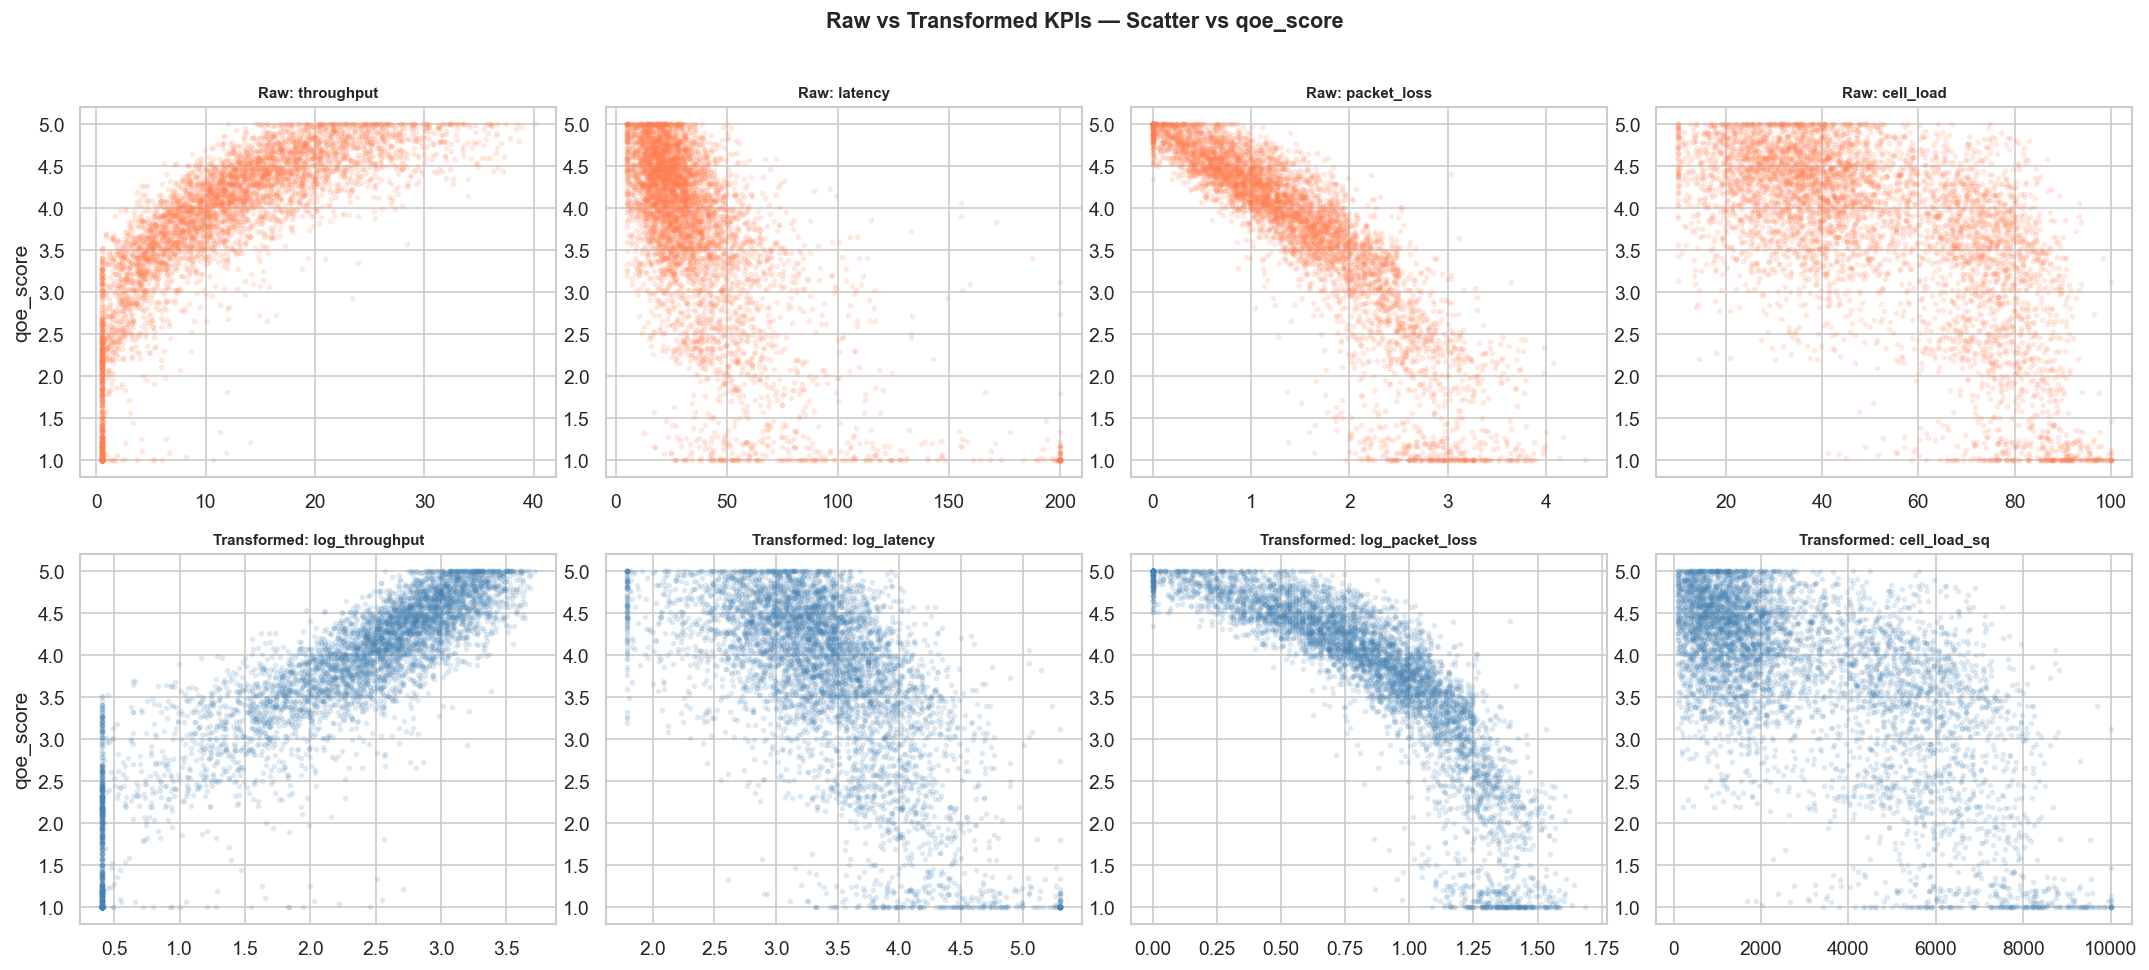

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
pairs = [("throughput","log_throughput"), ("latency","log_latency"),
         ("packet_loss","log_packet_loss"), ("cell_load","cell_load_sq")]

for i, (raw, trans) in enumerate(pairs):
    # raw
    axes[0, i].scatter(df[raw],   df[TARGET_R], alpha=0.12, s=6, color="coral")
    axes[0, i].set_title(f"Raw: {raw}", fontweight="bold", fontsize=9)
    axes[0, i].set_ylabel("qoe_score" if i==0 else "")
    # transformed
    axes[1, i].scatter(df[trans], df[TARGET_R], alpha=0.12, s=6, color="steelblue")
    axes[1, i].set_title(f"Transformed: {trans}", fontweight="bold", fontsize=9)
    axes[1, i].set_ylabel("qoe_score" if i==0 else "")

plt.suptitle("Raw vs Transformed KPIs — Scatter vs qoe_score", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 6  Binning & Categorical Encoding
Convert continuous KPIs and categorical columns into ordinal / dummy
features suited for tree-based and linear models.


In [12]:
# ── 6.1  KPI Binning (domain-threshold bins) ─────────────────────────
# Use -np.inf and np.inf to catch everything outside
df["sinr_tier"] = pd.cut(df["sinr"],
    bins=[-np.inf, 0, 7, 15, np.inf],       # ← -inf to +inf
    labels=[0, 1, 2, 3]).astype(int)

df["latency_tier"] = pd.cut(df["latency"],
    bins=[0, 30, 80, 150, np.inf],           # ← np.inf catches >200
    labels=[3, 2, 1, 0]).astype(int)

df["tput_tier"] = pd.cut(df["throughput"],
    bins=[0, 1, 5, 15, np.inf],              # ← np.inf catches >50
    labels=[0, 1, 2, 3]).astype(int)

df["load_tier"] = pd.cut(df["cell_load"],
    bins=[0, 30, 60, 85, np.inf],
    labels=[3, 2, 1, 0]).astype(int)

df["mobility_tier"] = pd.cut(df["mobility"],
    bins=[-np.inf, 5, 30, 80, np.inf],
    labels=[0, 1, 2, 3]).astype(int)

df["loss_tier"] = pd.cut(df["packet_loss"],
    bins=[-np.inf, 0.3, 1.0, 2.5, np.inf],
    labels=[3, 2, 1, 0]).astype(int)

new_bins = ["sinr_tier","latency_tier","tput_tier",
            "load_tier","mobility_tier","loss_tier"]
print(f"Binned features: {len(new_bins)}")

# ── 6.2  Composite Quality Score (sum of ordinal tiers) ───────────────
# Simple additive score: max=18 (everything excellent), min=0 (everything poor)
df["composite_quality"] = (
    df["sinr_tier"] + df["latency_tier"] + df["tput_tier"] +
    df["load_tier"] + df["mobility_tier"] + df["loss_tier"]
)
print(f"composite_quality range: {df['composite_quality'].min()} – {df['composite_quality'].max()}")

# ── 6.3  One-Hot Encoding for 'app' ───────────────────────────────────
app_dummies = pd.get_dummies(df["app"], prefix="app")   # app_gaming, app_video, app_volte
df = pd.concat([df, app_dummies], axis=1)
new_ohe = list(app_dummies.columns)
print(f"OHE app columns: {new_ohe}")

# ── 6.4  Label Encoding for qoe_category (for classification tasks) ───
le = LabelEncoder()
df["qoe_cat_label"] = le.fit_transform(df[TARGET_C])
print(f"qoe_cat_label mapping: { {c:i for i,c in enumerate(le.classes_)} }")

df[new_bins + ["composite_quality"]].describe().T.round(2)


Binned features: 6
composite_quality range: 0 – 17
OHE app columns: ['app_gaming', 'app_video', 'app_volte']
qoe_cat_label mapping: {'Excellent': 0, 'Fair': 1, 'Good': 2, 'Poor': 3}


,count,mean,std,min,25%,50%,75%,max
sinr_tier,5000.0,1.77,0.93,0.0,1.0,2.0,2.0,3.0
latency_tier,5000.0,2.46,0.65,0.0,2.0,3.0,3.0,3.0
tput_tier,5000.0,1.92,0.99,0.0,1.0,2.0,3.0,3.0
load_tier,5000.0,1.76,0.85,0.0,1.0,2.0,2.0,3.0
mobility_tier,5000.0,1.50,0.66,0.0,1.0,2.0,2.0,3.0
loss_tier,5000.0,1.29,0.80,0.0,1.0,1.0,2.0,3.0
composite_quality,5000.0,10.70,3.39,0.0,9.0,11.0,13.0,17.0


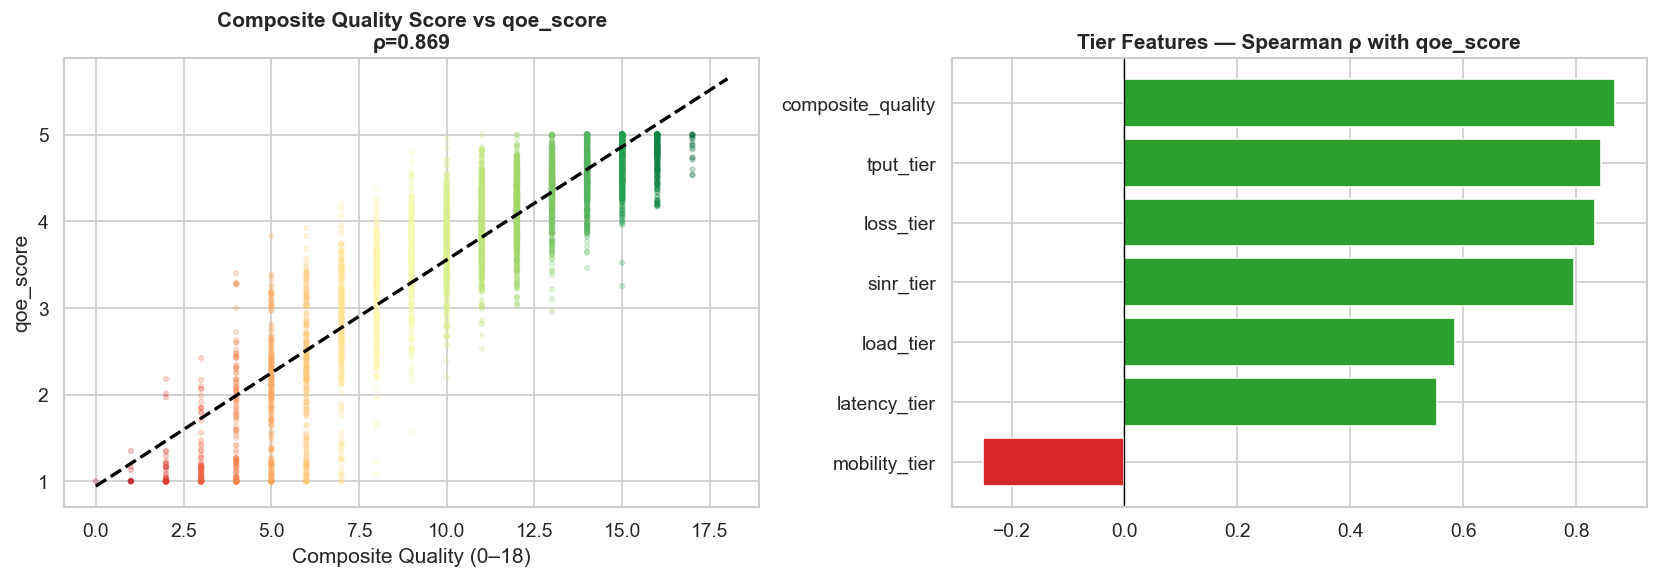

In [13]:
# Visualise composite_quality vs qoe_score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["composite_quality"], df[TARGET_R], alpha=0.2, s=8,
                c=df["composite_quality"], cmap="RdYlGn")
z = np.polyfit(df["composite_quality"], df[TARGET_R], 1)
xr = np.arange(0, 19)
axes[0].plot(xr, np.polyval(z, xr), "k--", lw=2)
rho = spearmanr(df["composite_quality"], df[TARGET_R])[0]
axes[0].set_title(f"Composite Quality Score vs qoe_score\nρ={rho:.3f}", fontweight="bold")
axes[0].set_xlabel("Composite Quality (0–18)")
axes[0].set_ylabel("qoe_score")

# Tier distribution heatmap
tier_corr = {col: spearmanr(df[col], df[TARGET_R])[0] for col in new_bins+["composite_quality"]}
tc = pd.Series(tier_corr).sort_values(ascending=True)
colors_tc = ["#2ca02c" if v>=0 else "#d62728" for v in tc.values]
axes[1].barh(tc.index, tc.values, color=colors_tc, edgecolor="white")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Tier Features — Spearman ρ with qoe_score", fontweight="bold")

plt.tight_layout()
plt.show()


## 7  Aggregated & Statistical Features
Row-level statistics across all KPIs capture **overall session health**.
These are especially useful when the model doesn't see per-KPI structure.


In [14]:
kpi_matrix = df[RAW_KPI].copy()

# Normalise each KPI to [0,1] first so they're comparable
kpi_norm = (kpi_matrix - kpi_matrix.min()) / (kpi_matrix.max() - kpi_matrix.min())

# ── 7.1  Row-level statistics ─────────────────────────────────────────
df["kpi_mean"]   = kpi_norm.mean(axis=1)
df["kpi_std"]    = kpi_norm.std(axis=1)      # high std → uneven KPI profile
df["kpi_min"]    = kpi_norm.min(axis=1)      # weakest KPI per session
df["kpi_max"]    = kpi_norm.max(axis=1)      # strongest KPI per session
df["kpi_range"]  = df["kpi_max"] - df["kpi_min"]   # spread across KPIs

# ── 7.2  Impairment vector ────────────────────────────────────────────
# Invert "bad" KPIs (latency, loss, load, prb, mobility) so that
# higher always = better; then compute mean as an overall health score
impairment_cols = ["latency","packet_loss","cell_load","prb_utilization","mobility"]
benefit_cols    = ["throughput","sinr","rsrp"]

kpi_imp_norm  = kpi_norm[impairment_cols]
kpi_ben_norm  = kpi_norm[benefit_cols]

df["avg_impairment"] = (1 - kpi_imp_norm).mean(axis=1)   # 1 = no impairment
df["avg_benefit"]    = kpi_ben_norm.mean(axis=1)
df["health_score"]   = 0.5*df["avg_benefit"] + 0.5*df["avg_impairment"]

# ── 7.3  Critical KPI count ───────────────────────────────────────────
# Number of KPIs in "bad" zone per session
df["n_kpi_poor"] = (
    (df["sinr"]          < 0  ).astype(int) +
    (df["latency"]       > 100).astype(int) +
    (df["packet_loss"]   > 1.5).astype(int) +
    (df["throughput"]    < 2  ).astype(int) +
    (df["cell_load"]     > 80 ).astype(int)
)

new_agg = ["kpi_mean","kpi_std","kpi_min","kpi_max","kpi_range",
           "avg_impairment","avg_benefit","health_score","n_kpi_poor"]

print(f"Aggregate features added: {len(new_agg)}")

# Correlation with target
agg_corr = pd.Series(
    {col: spearmanr(df[col], df[TARGET_R])[0] for col in new_agg}
).sort_values(key=abs, ascending=False)
print("\nSpearman ρ with qoe_score:")
print(agg_corr.round(4))


Aggregate features added: 9

Spearman ρ with qoe_score:
health_score      0.9052
n_kpi_poor       -0.8475
avg_benefit       0.8463
avg_impairment    0.7768
kpi_mean         -0.2905
kpi_max          -0.2064
kpi_range        -0.1994
kpi_std          -0.1579
kpi_min           0.1324
dtype: float64


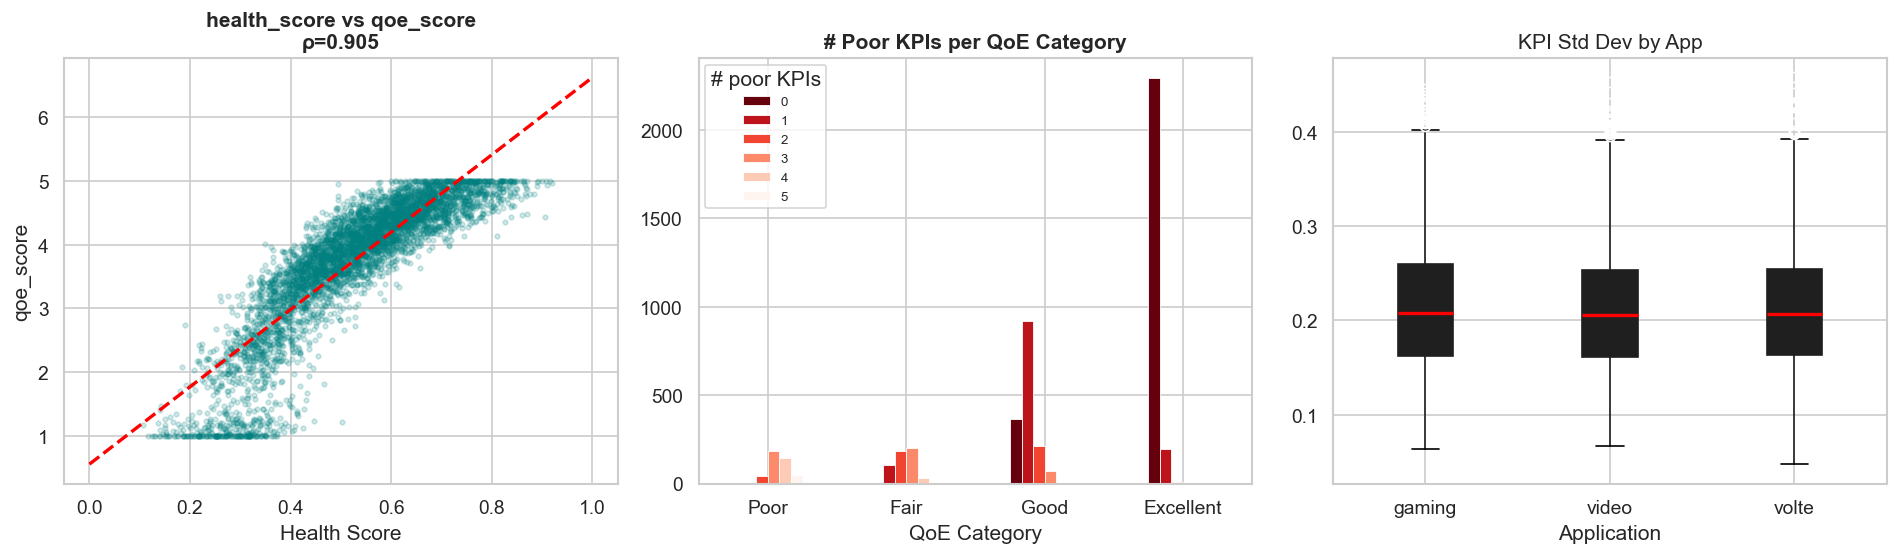

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# health_score vs qoe_score
axes[0].scatter(df["health_score"], df[TARGET_R], alpha=0.18, s=8, color="teal")
z = np.polyfit(df["health_score"], df[TARGET_R], 1)
xr = np.linspace(0, 1, 100)
axes[0].plot(xr, np.polyval(z, xr), "r--", lw=2)
rho = spearmanr(df["health_score"], df[TARGET_R])[0]
axes[0].set_title(f"health_score vs qoe_score\nρ={rho:.3f}", fontweight="bold")
axes[0].set_xlabel("Health Score")
axes[0].set_ylabel("qoe_score")

# n_kpi_poor distribution per QoE category
pivot = df.groupby(["qoe_category","n_kpi_poor"]).size().unstack(fill_value=0)
pivot.reindex(CAT_ORDER).plot(kind="bar", ax=axes[1], colormap="Reds_r",
                               edgecolor="white", linewidth=0.5)
axes[1].set_title("# Poor KPIs per QoE Category", fontweight="bold")
axes[1].set_xlabel("QoE Category")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="# poor KPIs", fontsize=8)

# kpi_std by app (uneven profiles)
df.boxplot(column="kpi_std", by="app", ax=axes[2],
           patch_artist=True, medianprops=dict(color="red",lw=2))
axes[2].set_title("KPI Std Dev by App", fontweight="bold")
axes[2].set_xlabel("Application")
plt.sca(axes[2]); plt.title("KPI Std Dev by App")
plt.suptitle("")

plt.tight_layout()
plt.show()


## 8  App-Specific Feature Flags
Each app has different **critical thresholds** (ITU-T G.1010 / 3GPP TS 22.261).
Boolean flags capture whether a session is in the degraded zone *for its specific app*.


In [16]:
# ── Per-app KPI threshold flags ───────────────────────────────────────

# Video: stall risk = tput < 2 Mbps; blockiness = loss > 1 %
df["video_stall_risk"]   = ((df["app"]=="video") & (df["throughput"] < 2.0)).astype(int)
df["video_loss_flag"]    = ((df["app"]=="video") & (df["packet_loss"] > 1.0)).astype(int)

# VoLTE: E-model cliff at lat > 150 ms; audible loss at > 0.5 %
df["volte_lat_cliff"]    = ((df["app"]=="volte") & (df["latency"]     > 150)).astype(int)
df["volte_loss_cliff"]   = ((df["app"]=="volte") & (df["packet_loss"] > 0.5)).astype(int)

# Gaming: unplayable latency > 120 ms; rubber-banding loss > 1.5 %
df["game_lat_cliff"]     = ((df["app"]=="gaming") & (df["latency"]     > 120)).astype(int)
df["game_loss_cliff"]    = ((df["app"]=="gaming") & (df["packet_loss"] > 1.5)).astype(int)

# General: poor signal / heavily loaded cell
df["poor_signal_flag"]   = (df["sinr"]      < 0  ).astype(int)
df["saturated_cell_flag"]= (df["cell_load"] > 85 ).astype(int)
df["high_mobility_flag"] = (df["mobility"]  > 80 ).astype(int)

new_flags = ["video_stall_risk","video_loss_flag","volte_lat_cliff","volte_loss_cliff",
             "game_lat_cliff","game_loss_cliff","poor_signal_flag",
             "saturated_cell_flag","high_mobility_flag"]

print(f"App-specific flags added: {len(new_flags)}")
print("\nFlag prevalence (% of sessions):")
print((df[new_flags].mean()*100).round(1).to_string())


App-specific flags added: 9

Flag prevalence (% of sessions):
video_stall_risk        5.0
video_loss_flag        21.3
volte_lat_cliff         0.5
volte_loss_cliff       29.2
game_lat_cliff          0.6
game_loss_cliff        15.2
poor_signal_flag       10.8
saturated_cell_flag     7.0
high_mobility_flag      3.1



QoE impact of each flag:
                     flag=0 (normal)  flag=1 (degraded)  delta
game_lat_cliff                 3.755              1.085 -2.670
volte_lat_cliff                3.752              1.085 -2.667
video_stall_risk               3.861              1.412 -2.448
saturated_cell_flag            3.875              1.921 -1.954
poor_signal_flag               3.944              2.037 -1.907
game_loss_cliff                3.893              2.872 -1.022
high_mobility_flag             3.758              3.127 -0.632
video_loss_flag                3.856              3.304 -0.553
volte_loss_cliff               3.813              3.559 -0.254


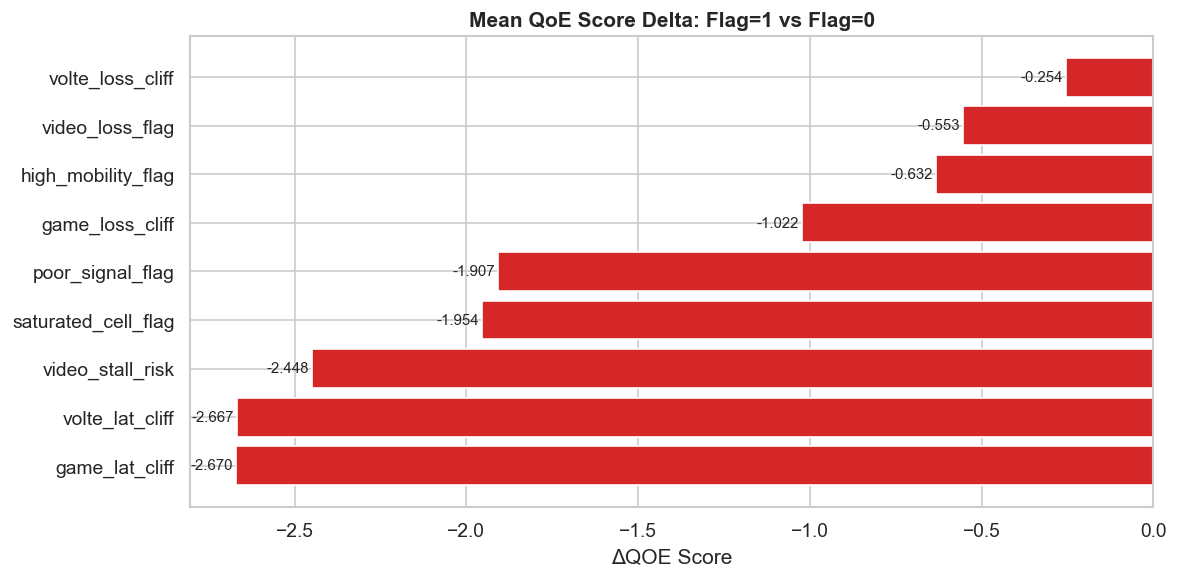

In [17]:
# Mean qoe_score when flag is 0 vs 1 for each flag
flag_impact = {}
for col in new_flags:
    m0 = df[df[col]==0][TARGET_R].mean()
    m1 = df[df[col]==1][TARGET_R].mean()
    flag_impact[col] = {"flag=0 (normal)": round(m0,3), "flag=1 (degraded)": round(m1,3),
                        "delta": round(m1-m0,3)}

fi_df = pd.DataFrame(flag_impact).T.sort_values("delta")
print("\nQoE impact of each flag:")
print(fi_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors_d = ["#d62728" if v<0 else "#2ca02c" for v in fi_df["delta"].values]
ax.barh(fi_df.index, fi_df["delta"].values, color=colors_d, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Mean QoE Score Delta: Flag=1 vs Flag=0", fontweight="bold")
ax.set_xlabel("ΔQOE Score")
for i,v in enumerate(fi_df["delta"].values):
    ax.text(v + (0.01 if v>=0 else -0.01), i, f"{v:+.3f}",
            va="center", ha="left" if v>=0 else "right", fontsize=9)
plt.tight_layout()
plt.show()


## 9  Feature Scaling
Different scalers suit different model families:
- **StandardScaler** → linear models, SVMs, neural networks
- **MinMaxScaler** → when bounded [0,1] input is required
- **RobustScaler** → when outliers are present (uses IQR)


In [18]:
# Collect all engineered numeric features (exclude targets, IMSI, raw categoricals)
EXCLUDE = ["imsi","app","qoe_category","qoe_cat_label",TARGET_R] + list(app_dummies.columns)
ALL_FEATURES = [c for c in df.columns if c not in EXCLUDE
                and df[c].dtype in [np.float64, np.float32, np.int64, np.int32, int, float]]

print(f"Total engineered features: {len(ALL_FEATURES)}")
print("\nFeature list:")
for i, f in enumerate(ALL_FEATURES):
    print(f"  {i+1:>3}. {f}")


Total engineered features: 61

Feature list:
    1. throughput
    2. latency
    3. packet_loss
    4. sinr
    5. rsrp
    6. cell_load
    7. prb_utilization
    8. mobility
    9. shannon_capacity
   10. spectral_efficiency
   11. rsrp_sinr_gap
   12. lqi
   13. congestion_index
   14. congestion_index_sq
   15. goodput
   16. ho_risk
   17. r_factor_proxy
   18. mos_from_r
   19. tput_lat_ratio
   20. sinr_x_tput
   21. loss_x_latency
   22. load_x_mobility
   23. sinr_per_prb
   24. goodput_lat_ratio
   25. free_prb_ratio
   26. lqi_x_free_prb
   27. log_throughput
   28. log_latency
   29. log_packet_loss
   30. log_mobility
   31. sqrt_throughput
   32. sqrt_cell_load
   33. cell_load_sq
   34. latency_sq
   35. packet_loss_sq
   36. sinr_exp
   37. sinr_tier
   38. latency_tier
   39. tput_tier
   40. load_tier
   41. mobility_tier
   42. loss_tier
   43. composite_quality
   44. kpi_mean
   45. kpi_std
   46. kpi_min
   47. kpi_max
   48. kpi_range
   49. avg_impairment
   50

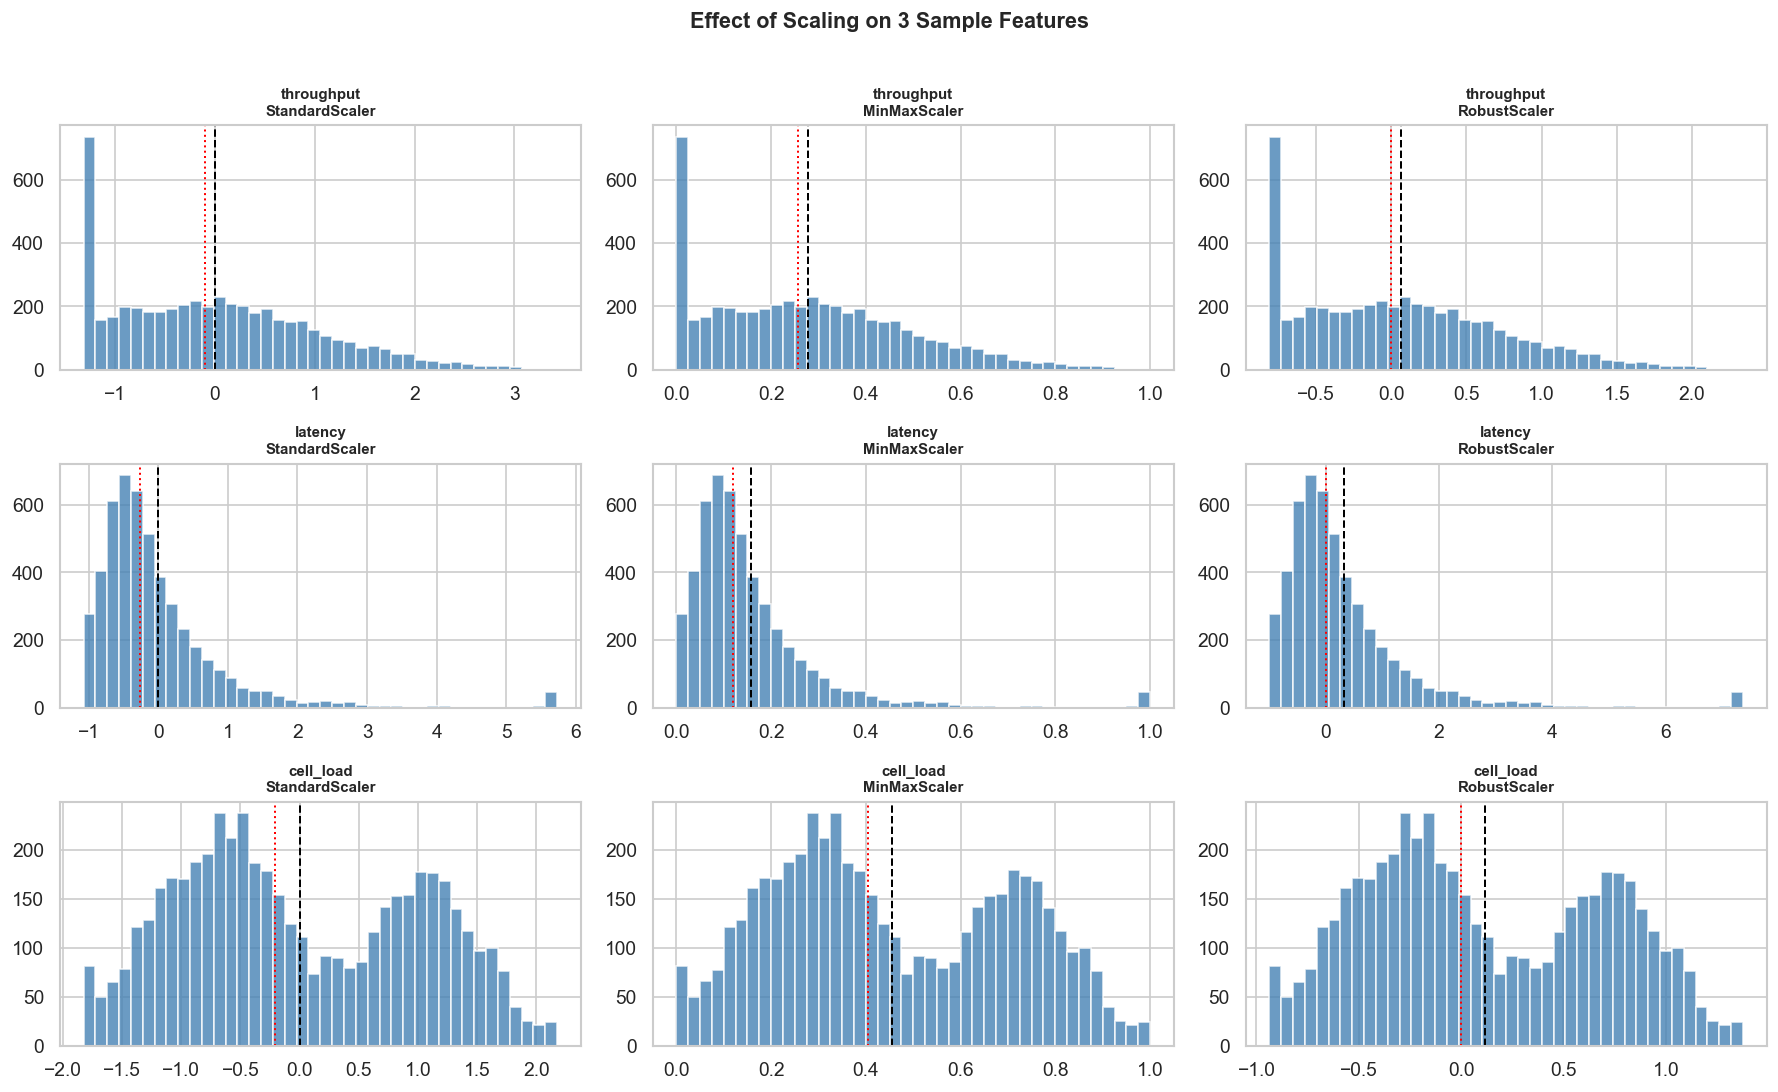

Recommendation:
  • StandardScaler  → Logistic Regression, SVM, MLP
  • MinMaxScaler    → KNN, neural nets requiring [0,1]
  • RobustScaler    → When latency/mobility outliers exist (default choice here)


In [19]:
X_raw = df[ALL_FEATURES].astype(float)
y     = df[TARGET_R].values

# ── Fit three scalers ─────────────────────────────────────────────────
std_scaler    = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

X_std    = pd.DataFrame(std_scaler.fit_transform(X_raw),    columns=ALL_FEATURES)
X_minmax = pd.DataFrame(minmax_scaler.fit_transform(X_raw), columns=ALL_FEATURES)
X_robust = pd.DataFrame(robust_scaler.fit_transform(X_raw), columns=ALL_FEATURES)

# Compare distributions of 3 sample features after each scaling
sample_feats = ["throughput", "latency", "cell_load"]
fig, axes = plt.subplots(3, 3, figsize=(15, 9))

scaler_data = {"StandardScaler": X_std,
               "MinMaxScaler":   X_minmax,
               "RobustScaler":   X_robust}

for col_i, feat in enumerate(sample_feats):
    for row_i, (sname, Xs) in enumerate(scaler_data.items()):
        ax = axes[col_i][row_i]
        ax.hist(Xs[feat], bins=40, color="steelblue", alpha=0.8, edgecolor="white")
        ax.set_title(f"{feat}\n{sname}", fontsize=9, fontweight="bold")
        ax.axvline(Xs[feat].mean(),   color="black", lw=1.2, ls="--")
        ax.axvline(Xs[feat].median(), color="red",   lw=1.2, ls=":")

plt.suptitle("Effect of Scaling on 3 Sample Features", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Recommendation:")
print("  • StandardScaler  → Logistic Regression, SVM, MLP")
print("  • MinMaxScaler    → KNN, neural nets requiring [0,1]")
print("  • RobustScaler    → When latency/mobility outliers exist (default choice here)")


## 10  Feature Selection
Three complementary methods to identify the most predictive features:
- **Filter** — Mutual Information (model-agnostic)
- **Embedded** — Lasso regularisation (linear model)
- **Embedded** — Random Forest feature importance (tree-based)


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import mutual_info_regression

X = X_robust.copy()   # use robust-scaled features throughout

# ── 10.1  Mutual Information (Filter) ────────────────────────────────
mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=ALL_FEATURES).sort_values(ascending=False)

# ── 10.2  Lasso (Embedded — linear) ──────────────────────────────────
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X, y)
lasso_coef = pd.Series(np.abs(lasso.coef_), index=ALL_FEATURES).sort_values(ascending=False)
lasso_selected = lasso_coef[lasso_coef > 0].index.tolist()
print(f"Lasso selected {len(lasso_selected)} / {len(ALL_FEATURES)} features (α={lasso.alpha_:.5f})")

# ── 10.3  Random Forest Importance (Embedded — tree) ─────────────────
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_imp = pd.Series(rf.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)

print("\nTop 15 features by each method:")
comparison_df = pd.DataFrame({
    "MI_rank":    mi_series.rank(ascending=False).astype(int),
    "Lasso_rank": lasso_coef.rank(ascending=False).astype(int),
    "RF_rank":    rf_imp.rank(ascending=False).astype(int),
})
comparison_df["mean_rank"] = comparison_df.mean(axis=1)
comparison_df = comparison_df.sort_values("mean_rank")
print(comparison_df.head(20).to_string())


Lasso selected 27 / 61 features (α=0.00180)

Top 15 features by each method:
                   MI_rank  Lasso_rank  RF_rank  mean_rank
packet_loss              4           3       12   6.333333
goodput_lat_ratio        9          19        1   9.666667
packet_loss_sq           3          13       14  10.000000
log_throughput           8           2       20  10.000000
tput_lat_ratio          10          20        2  10.666667
loss_x_latency          16          14        6  12.000000
sinr_x_tput             14          15       13  14.000000
r_factor_proxy           1          44        3  16.000000
mos_from_r               2          44        4  16.666667
sinr_per_prb            15          25       15  18.333333
video_stall_risk        48           1        7  18.666667
goodput                  7          44        5  18.666667
log_packet_loss          5          44        9  19.333333
sinr_exp                24           8       27  19.666667
health_score             6          44

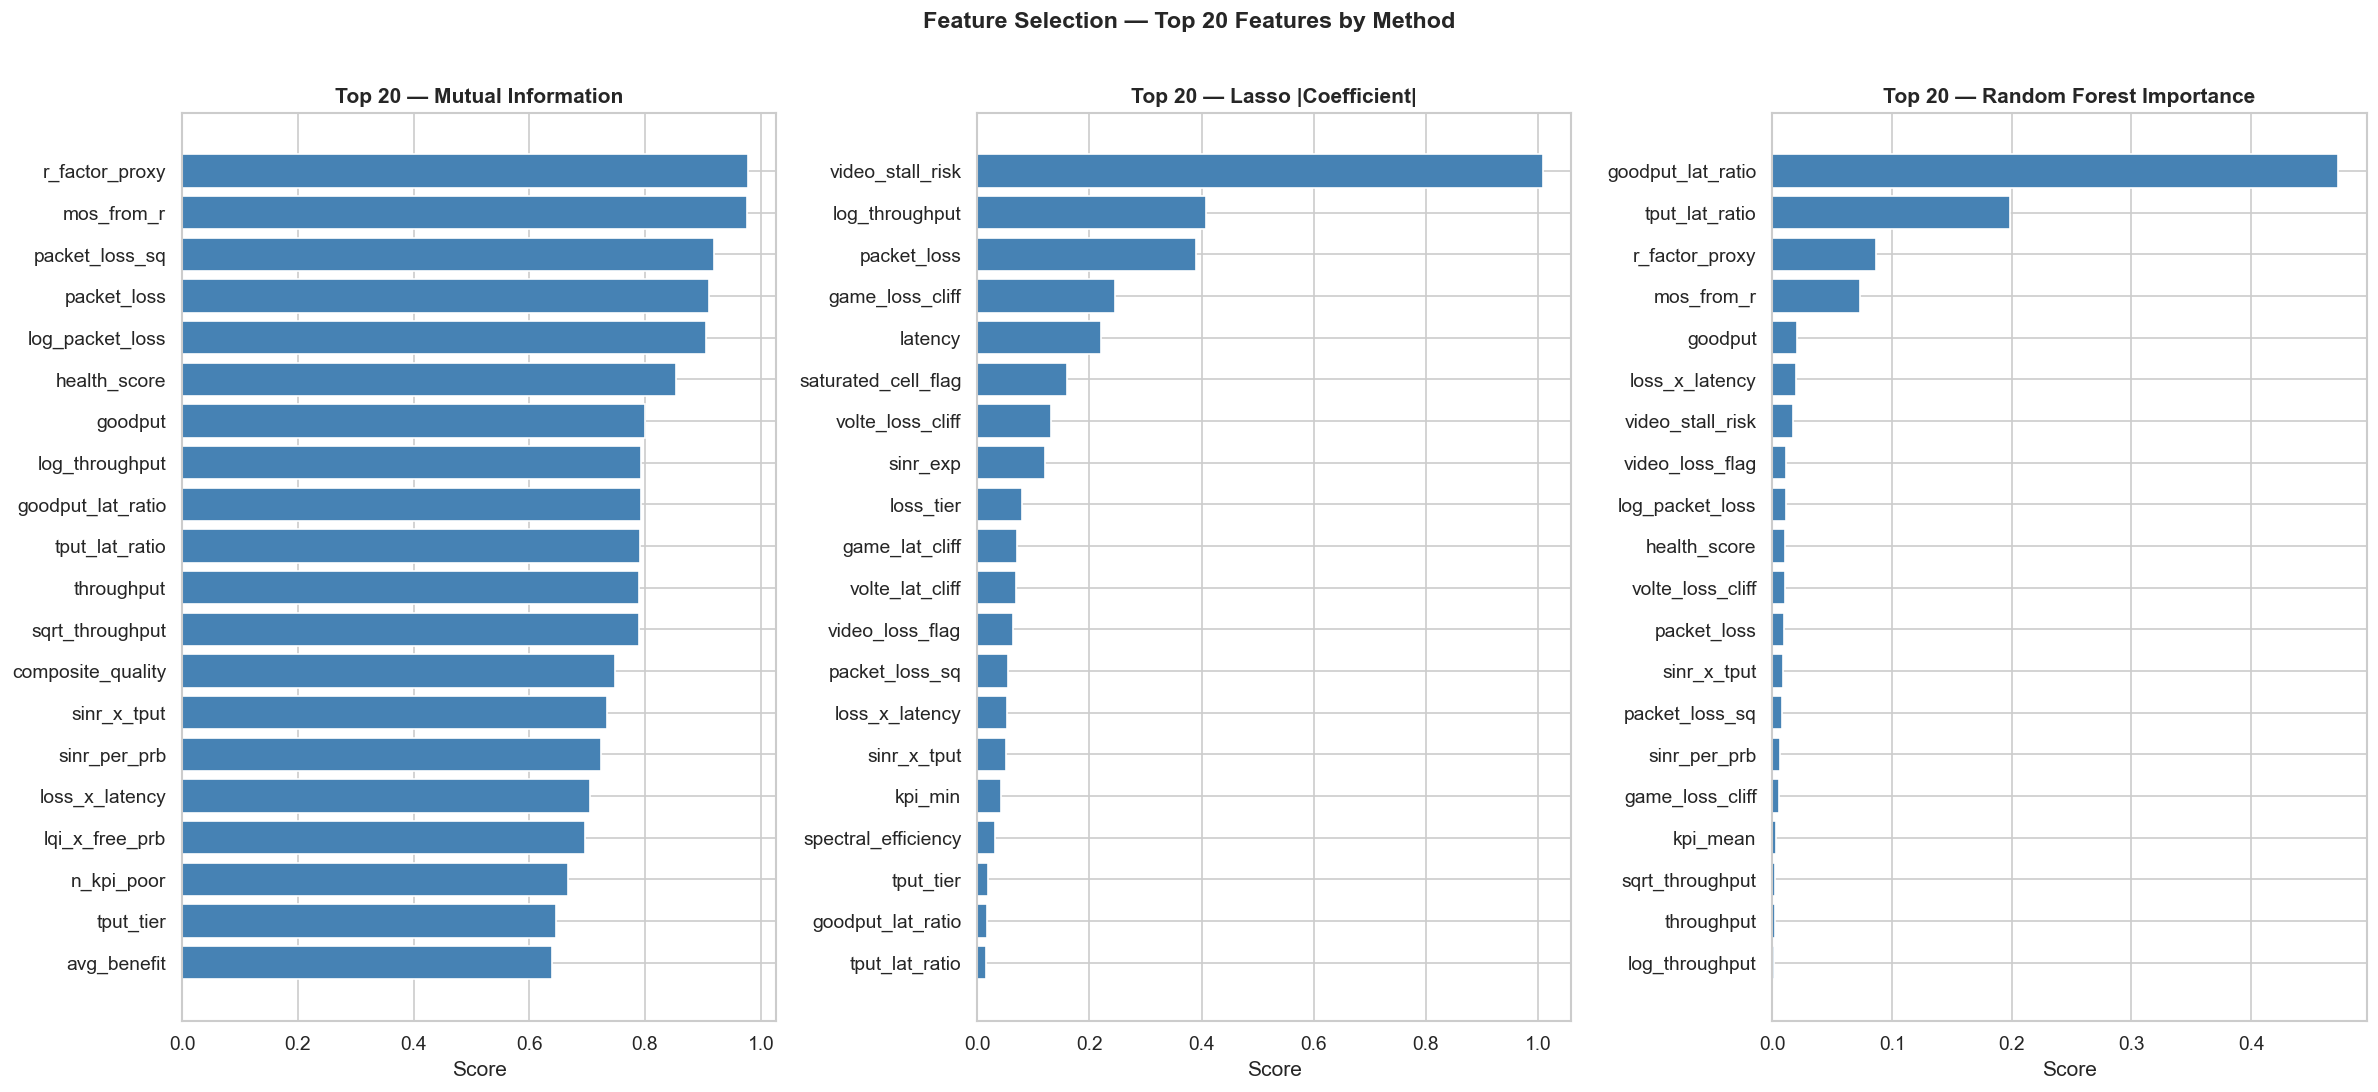

In [21]:
TOP_N = 20
fig, axes = plt.subplots(1, 3, figsize=(20, 9))

for ax, (name, series) in zip(axes, [
    ("Mutual Information",      mi_series.head(TOP_N)),
    ("Lasso |Coefficient|",     lasso_coef.head(TOP_N)),
    ("Random Forest Importance",rf_imp.head(TOP_N)),
]):
    ax.barh(series.index[::-1], series.values[::-1], color="steelblue", edgecolor="white")
    ax.set_title(f"Top {TOP_N} — {name}", fontweight="bold")
    ax.set_xlabel("Score")

plt.suptitle("Feature Selection — Top 20 Features by Method", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [22]:
# ── Consensus: features ranked in top-20 by ALL three methods ─────────
top20_mi    = set(mi_series.head(20).index)
top20_lasso = set(lasso_coef.head(20).index)
top20_rf    = set(rf_imp.head(20).index)

consensus_all   = top20_mi & top20_lasso & top20_rf
consensus_any2  = (top20_mi & top20_lasso) | (top20_mi & top20_rf) | (top20_lasso & top20_rf)

print(f"Features in top-20 for ALL 3 methods ({len(consensus_all)}):")
for f in sorted(consensus_all): print(f"  ✓ {f}")

print(f"\nFeatures in top-20 for at least 2 methods ({len(consensus_any2)}):")
for f in sorted(consensus_any2): print(f"  • {f}")

FINAL_FEATURES = sorted(consensus_any2, key=lambda f: comparison_df.loc[f,"mean_rank"])
print(f"\n→ Final selected feature set: {len(FINAL_FEATURES)} features")


Features in top-20 for ALL 3 methods (7):
  ✓ goodput_lat_ratio
  ✓ log_throughput
  ✓ loss_x_latency
  ✓ packet_loss
  ✓ packet_loss_sq
  ✓ sinr_x_tput
  ✓ tput_lat_ratio

Features in top-20 for at least 2 methods (20):
  • game_loss_cliff
  • goodput
  • goodput_lat_ratio
  • health_score
  • log_packet_loss
  • log_throughput
  • loss_x_latency
  • mos_from_r
  • packet_loss
  • packet_loss_sq
  • r_factor_proxy
  • sinr_per_prb
  • sinr_x_tput
  • sqrt_throughput
  • throughput
  • tput_lat_ratio
  • tput_tier
  • video_loss_flag
  • video_stall_risk
  • volte_loss_cliff

→ Final selected feature set: 20 features


## 11  Final Feature Matrix
Assemble the selected features into the final ML-ready DataFrame and
run a last correlation heatmap to check for multicollinearity.


In [23]:
df_final = X_robust[FINAL_FEATURES].copy()
df_final[TARGET_R]  = df[TARGET_R].values
df_final[TARGET_C]  = df[TARGET_C].values
df_final["app"]     = df["app"].values

print(f"Final feature matrix shape: {df_final.shape}")
print(f"Features: {FINAL_FEATURES}")
df_final.head()


Final feature matrix shape: (5000, 23)
Features: ['packet_loss', 'goodput_lat_ratio', 'log_throughput', 'packet_loss_sq', 'tput_lat_ratio', 'loss_x_latency', 'sinr_x_tput', 'r_factor_proxy', 'mos_from_r', 'sinr_per_prb', 'goodput', 'video_stall_risk', 'log_packet_loss', 'health_score', 'volte_loss_cliff', 'game_loss_cliff', 'sqrt_throughput', 'throughput', 'video_loss_flag', 'tput_tier']


,packet_loss,goodput_lat_ratio,log_throughput,packet_loss_sq,tput_lat_ratio,loss_x_latency,sinr_x_tput,r_factor_proxy,mos_from_r,sinr_per_prb,...,health_score,volte_loss_cliff,game_loss_cliff,sqrt_throughput,throughput,video_loss_flag,tput_tier,qoe_score,qoe_category,app
0,1.021956,-0.404050,-0.664202,1.447390,-0.404216,1.150033,-0.368695,-0.919458,-0.976224,-0.400720,...,-0.819618,0.0,1.0,-0.595706,-0.510554,0.0,-0.5,2.77,Fair,gaming
1,-0.423154,0.746984,0.116578,-0.330807,0.746906,-0.375807,0.153150,0.478147,0.459056,0.746680,...,0.380030,1.0,0.0,0.127741,0.139387,0.0,0.0,4.45,Excellent,volte
2,-0.367265,0.723372,0.563734,-0.296128,0.724138,-0.203502,1.241051,0.370612,0.358962,1.680457,...,0.691206,1.0,0.0,0.702265,0.896854,0.0,0.5,4.28,Excellent,volte
3,-0.822355,1.593873,0.804689,-0.498744,1.585068,-0.442477,2.572526,0.850890,0.791132,1.344589,...,1.087618,0.0,0.0,1.077995,1.507766,0.0,0.5,4.45,Excellent,gaming
4,0.638723,-0.460553,-1.176559,0.797139,-0.462352,0.439615,-0.414315,-0.552880,-0.573280,-0.453380,...,-0.597428,0.0,0.0,-0.945467,-0.703305,1.0,-0.5,2.32,Fair,video


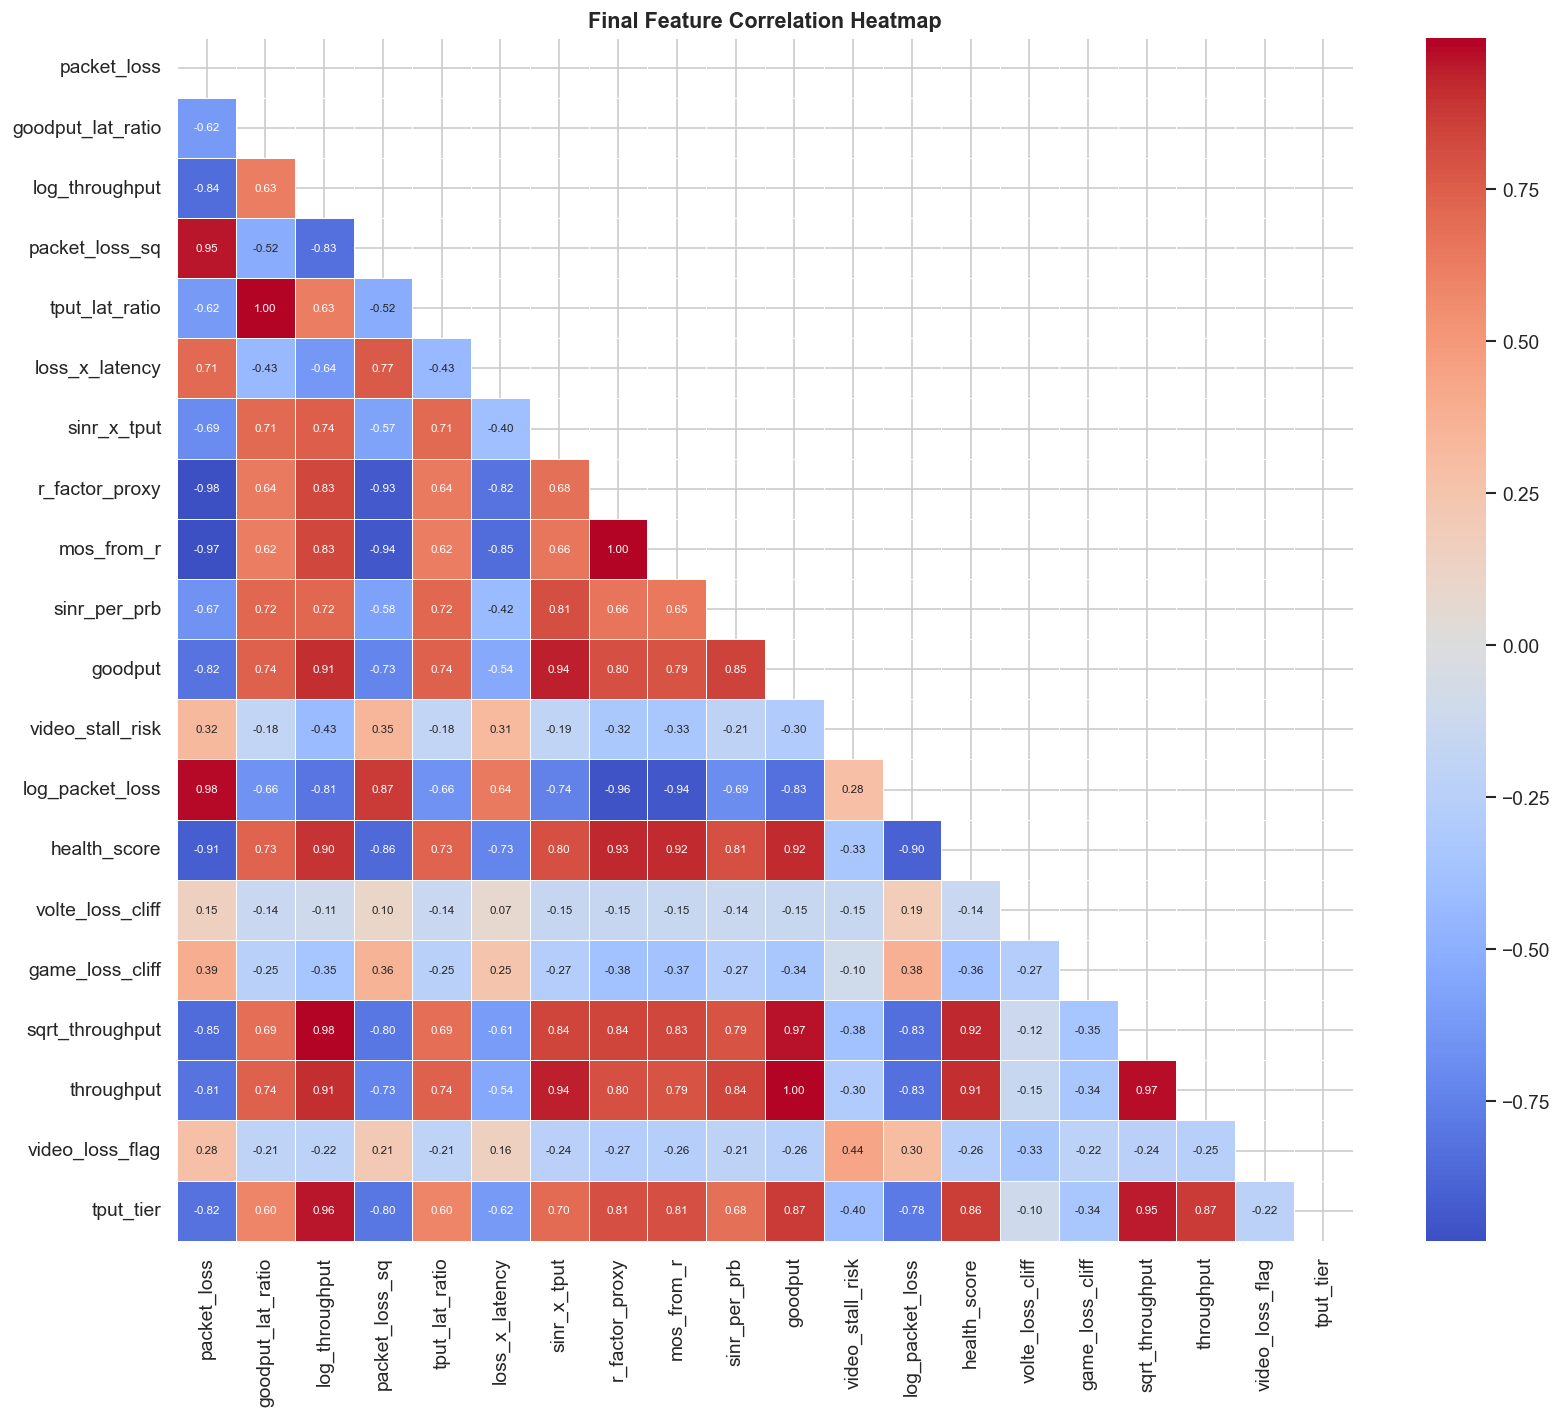


⚠  Highly correlated pairs (|r|>0.90) — consider dropping one of each:
   packet_loss  ↔  packet_loss_sq  r=0.954
   packet_loss  ↔  r_factor_proxy  r=-0.98
   packet_loss  ↔  mos_from_r  r=-0.973
   packet_loss  ↔  log_packet_loss  r=0.978
   packet_loss  ↔  health_score  r=-0.914
   goodput_lat_ratio  ↔  tput_lat_ratio  r=1.0
   log_throughput  ↔  goodput  r=0.911
   log_throughput  ↔  sqrt_throughput  r=0.985
   log_throughput  ↔  throughput  r=0.913
   log_throughput  ↔  tput_tier  r=0.961
   packet_loss_sq  ↔  r_factor_proxy  r=-0.932
   packet_loss_sq  ↔  mos_from_r  r=-0.943
   sinr_x_tput  ↔  goodput  r=0.94
   sinr_x_tput  ↔  throughput  r=0.938
   r_factor_proxy  ↔  mos_from_r  r=0.998
   r_factor_proxy  ↔  log_packet_loss  r=-0.961
   r_factor_proxy  ↔  health_score  r=0.926
   mos_from_r  ↔  log_packet_loss  r=-0.943
   mos_from_r  ↔  health_score  r=0.92
   goodput  ↔  health_score  r=0.915
   goodput  ↔  sqrt_throughput  r=0.969
   goodput  ↔  throughput  r=1.0
   log_pa

In [24]:
# Correlation heatmap of final features
corr_final = df_final[FINAL_FEATURES].corr()

# Flag highly correlated pairs (|r| > 0.90) as candidates for removal
high_corr_pairs = []
for i in range(len(corr_final.columns)):
    for j in range(i+1, len(corr_final.columns)):
        r = corr_final.iloc[i,j]
        if abs(r) > 0.90:
            high_corr_pairs.append((corr_final.columns[i], corr_final.columns[j], round(r,3)))

fig, ax = plt.subplots(figsize=(max(10, len(FINAL_FEATURES)*0.7),
                                max(8,  len(FINAL_FEATURES)*0.6)))
mask = np.triu(np.ones_like(corr_final, dtype=bool))
sns.heatmap(corr_final, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size":7})
ax.set_title("Final Feature Correlation Heatmap", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

if high_corr_pairs:
    print("\n⚠  Highly correlated pairs (|r|>0.90) — consider dropping one of each:")
    for a,b,r in high_corr_pairs:
        print(f"   {a}  ↔  {b}  r={r}")
else:
    print("\n✓ No pairs with |r| > 0.90 in final feature set.")


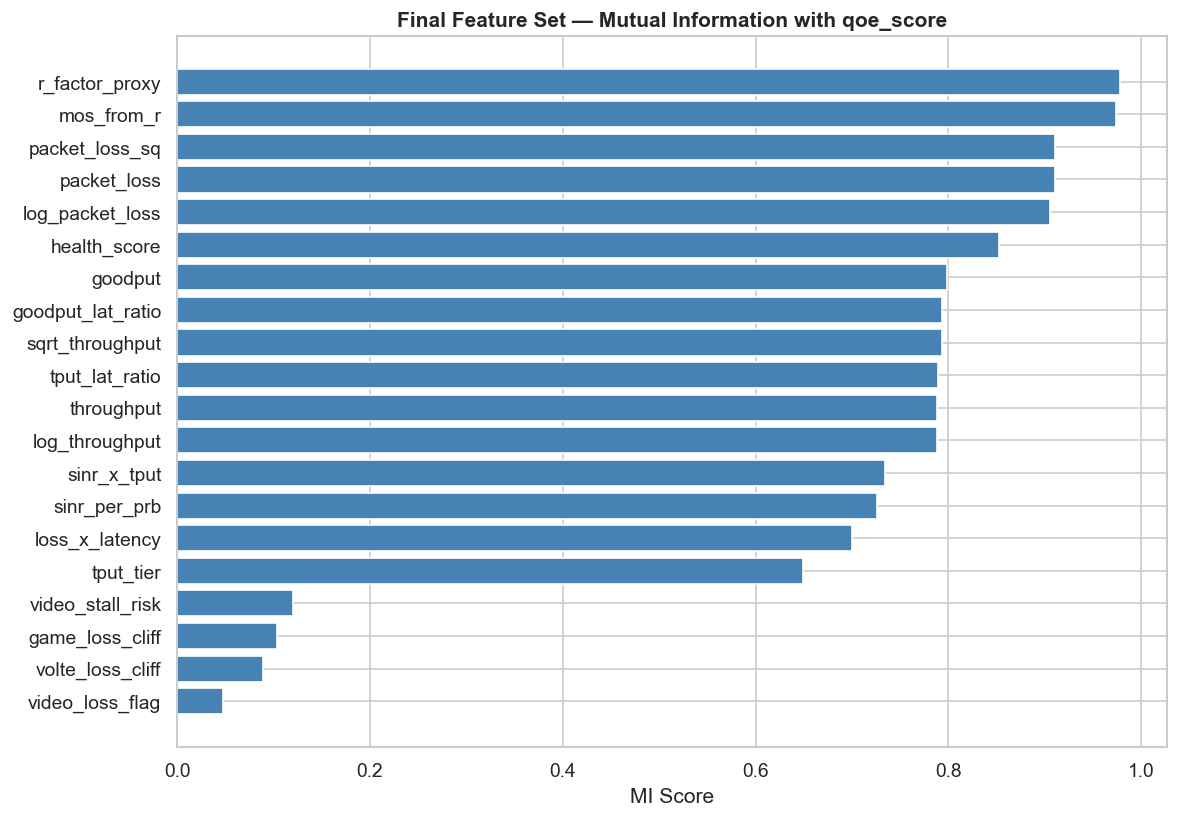

In [25]:
# Final MI score of selected features
mi_final = mutual_info_regression(df_final[FINAL_FEATURES], df_final[TARGET_R], random_state=42)
mi_final_s = pd.Series(mi_final, index=FINAL_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(FINAL_FEATURES)*0.35)))
ax.barh(mi_final_s.index, mi_final_s.values, color="steelblue", edgecolor="white")
ax.set_title("Final Feature Set — Mutual Information with qoe_score", fontweight="bold")
ax.set_xlabel("MI Score")
plt.tight_layout()
plt.show()


## 12  Export

In [26]:
# ── Save full feature-engineered DataFrame ────────────────────────────
df_export_full = df[["imsi","app"] + ALL_FEATURES + [TARGET_R, TARGET_C]].copy()
df_export_full.to_csv("telecom_qoe_features_full.csv", index=False)
print(f"Full feature set saved: {df_export_full.shape}  →  telecom_qoe_features_full.csv")

# ── Save ML-ready (scaled, selected) DataFrame ────────────────────────
df_final.to_csv("telecom_qoe_features_ml_ready.csv", index=False)
print(f"ML-ready set saved:    {df_final.shape}  →  telecom_qoe_features_ml_ready.csv")

# ── Feature Engineering Summary ───────────────────────────────────────
summary = {
    "Raw KPI features":             len(RAW_KPI),
    "Domain-derived features":      len(new_domain),
    "Interaction/ratio features":   len(new_interaction),
    "Polynomial/transform features":len(new_poly),
    "Binned/ordinal features":      len(new_bins) + 1,
    "Aggregate/statistical features":len(new_agg),
    "App-specific flag features":   len(new_flags),
    "OHE app features":             len(new_ohe),
    "TOTAL engineered features":    len(ALL_FEATURES),
    "FINAL selected features":      len(FINAL_FEATURES),
}
print("\n" + "="*50)
print("FEATURE ENGINEERING SUMMARY")
print("="*50)
for k,v in summary.items():
    marker = "→" if "FINAL" in k or "TOTAL" in k else " "
    print(f"  {marker} {k:<38}: {v}")


Full feature set saved: (5000, 65)  →  telecom_qoe_features_full.csv
ML-ready set saved:    (5000, 23)  →  telecom_qoe_features_ml_ready.csv

FEATURE ENGINEERING SUMMARY
    Raw KPI features                      : 8
    Domain-derived features               : 10
    Interaction/ratio features            : 8
    Polynomial/transform features         : 10
    Binned/ordinal features               : 7
    Aggregate/statistical features        : 9
    App-specific flag features            : 9
    OHE app features                      : 3
  → TOTAL engineered features             : 61
  → FINAL selected features               : 20


## Feature Engineering Summary

| Stage | Features Added | Purpose |
|---|---|---|
| **Raw KPIs** | 8 | Baseline inputs from network measurements |
| **Domain-derived** | 10 | Shannon capacity, LQI, R-factor, handover risk, goodput |
| **Interaction / ratio** | 8 | Joint effects (tput×sinr, loss×latency, load×mobility) |
| **Polynomial / log** | 10 | Non-linear transforms matching real degradation curves |
| **Binning / ordinal** | 7 | Threshold-based tiers per 3GPP / ITU-T standards |
| **Aggregate stats** | 9 | Per-row health score, # poor KPIs, benefit/impairment avg |
| **App-specific flags** | 9 | Boolean cliff indicators per app (stall, E-model, desync) |
| **OHE (app)** | 3 | Categorical encoding for app type |
| **Total engineered** | ~64 | Full feature space before selection |
| **Final selected** | varies | Consensus top features from MI + Lasso + RF |

**Scaler recommendation**: `RobustScaler` — handles latency and mobility outliers best.
